# Research Question 1
**Question:**  
What patterns of asymmetric price transmission can be observed between raw milk producer prices and retail butter prices in Germany?

Damit der code leichter zu verstehen ist haben wir es in zellen aufgeteilt 

1. Imports
2. Configuration
3. Helper functions
4. Data loading and cleaning
5. Feature engineering
6. Descriptive asymmetry metrics
7. At least different chart types

## Required local files
The APIs we use:

- `eurostat_ppi_dairy.json`
- `eurostat_butter_cpi.json`



In [59]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 1. Configuration



In [60]:
# Arbeiten im aktuellen Ordner
BASE_DIR = Path(".")

# Mandatory input files.
# Pfade werden zur Datei gespeichert
PPI_FILE = BASE_DIR / "eurostat_ppi_dairy.json"
CPI_FILE = BASE_DIR / "eurostat_butter_cpi.json"

# Optional FAOSTAT file.
FAOSTAT_FILE = BASE_DIR / "faostat_raw_milk_prices.csv"
USE_FAOSTAT = False

# Analysis period.
# Zeitraum der Analyse wir definiert
ANALYSIS_START = pd.Timestamp("2020-01-01")
ANALYSIS_END = pd.Timestamp("2024-12-31")

# Threshold used to classify monthly changes.
STABLE_THRESHOLD = 0.10


## 2. Helper function: Read Eurostat / Destatis JSON

This function converts the nested JSON structure into a clean two-column time series.

Diese Funktion liest eine Eurostat-JSON-Datei ein und wandelt sie in eine saubere monatliche pandas-Tabelle (DataFrame) um. Dabei wird zunächst der Zeitindex aus der Datei extrahiert und mit den zugehörigen Positionswerten verknüpft. Anschließend werden für jeden Monat einzelne Zeilen erstellt. Danach wird das Datumsformat in ein korrektes Zeitformat umgewandelt und schließlich wird sichergestellt, dass alle Werte numerisch sind.


In [61]:
def eurostat_json_to_df(file_path: Path, value_name: str) -> pd.DataFrame:
# Diese Funktion liest eine Eurostat JSON Datei ein
# und wandelt sie in eine pandas Tabelle um.
# sier erstellt daraus eine monahtliche Tabelle
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    time_index = data["dimension"]["time"]["category"]["index"]
    time_labels = data["dimension"]["time"]["category"]["label"]
    # Hier stehen die eigentlichen Preiswerte.
    values = data["value"]

    rows = []
    # Hier speichern wir später jede Zeile der Tabelle.

# schleife durch alle monate 
    for label_key, position in time_index.items():
        position_str = str(position)

        # Only keep months that actually contain a value. (Eurostat hat manchmal fehlende Werte.)
        if position_str in values:
            rows.append(
                {
                    "datum_raw": time_labels[label_key],
                    value_name: values[position_str],
                }
            )

    df = pd.DataFrame(rows) # panda tabelle

    # Convert labels such as "2020M01" into monthly timestamps.
    df["datum"] = pd.to_datetime(
        df["datum_raw"].str.replace("M", "-", regex=False),
        format="%Y-%m",
        errors="coerce",
    )

    df.drop(columns=["datum_raw"], inplace=True)

    # Force numeric conversion so invalid strings become NaN.
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")

    return df


## 3. Helper function: Read optional FAOSTAT CSV

This function is intentionally flexible because column names can differ between exports.

Diese Funktion lädt eine CSV-Datei aus FAOSTAT und wandelt sie in eine saubere Zeitreihe um. Zuerst wird die Datei eingelesen und anschließend wird automatisch nach einer passenden Datums- und Wertespalte gesucht. Danach werden nur diese beiden Spalten übernommen, in ein einheitliches Format umbenannt und die Datums- sowie Preiswerte in das richtige Datenformat umgewandelt. Am Ende gibt die Funktion eine bereinigte Tabelle mit den Spalten Datum und Rohmilchpreis zurück.

In [62]:
def load_faostat_csv(
    file_path: Path,
    date_candidates=None,
    value_candidates=None,
) -> pd.DataFrame:
    """
    Load a FAOSTAT-style CSV and map it to a standard monthly time series.

    Notes
    -----
    This function expects one date column and one value column.
    It is written defensively so that it fails with a helpful message if the
    expected columns are not available.
    """
    if date_candidates is None:
        date_candidates = ["date", "datum", "month", "year_month", "time"]

    if value_candidates is None:
        value_candidates = ["value", "preis", "price", "milk_price", "raw_milk_price"]

    df = pd.read_csv(file_path)

    date_column = None
    value_column = None

    for candidate in date_candidates:
        if candidate in df.columns:
            date_column = candidate
            break

    for candidate in value_candidates:
        if candidate in df.columns:
            value_column = candidate
            break

    if date_column is None:
        raise ValueError(
            "No usable date column was found in the FAOSTAT file. "
            "Please adjust date_candidates in the notebook."
        )

    if value_column is None:
        raise ValueError(
            "No usable value column was found in the FAOSTAT file. "
            "Please adjust value_candidates in the notebook."
        )

    output_df = df[[date_column, value_column]].copy()
    output_df.columns = ["datum", "raw_milk_price"]

    output_df["datum"] = pd.to_datetime(output_df["datum"], errors="coerce")
    output_df["raw_milk_price"] = pd.to_numeric(
        output_df["raw_milk_price"],
        errors="coerce",
    )

    return output_df

## 4. Helper function: Clean a monthly time series

This is the central data-cleaning step.
Diese Funktion bereinigt eine monatliche Zeitreihe.


fehlende Daten entfernen
 fehlende Werte entfernen
doppelte Monate löschen
 nach Datum sortieren
nur gewünschten Zeitraum behalten


In [63]:
def clean_time_series(
    df: pd.DataFrame, # ursprüngliche Taelle
    value_column: str, # name der preisspalte
    start_date: pd.Timestamp, # startdatum 
    end_date: pd.Timestamp, # enddatum
) -> pd.DataFrame:
    """
    Clean a monthly time series.

    Cleaning steps
    --------------
    - remove missing dates,
    - remove missing values,
    - remove duplicate months,
    - sort chronologically,
    - restrict the time window.

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame with one row per month.
    """
    cleaned_df = df.copy() # damit orig. nicht verändert wird

    cleaned_df = cleaned_df.dropna(subset=["datum", value_column])
    cleaned_df = cleaned_df.drop_duplicates(subset=["datum"], keep="last")
    cleaned_df = cleaned_df.sort_values("datum").reset_index(drop=True)

    cleaned_df = cleaned_df[
        (cleaned_df["datum"] >= start_date) & (cleaned_df["datum"] <= end_date)
    ].copy()

    return cleaned_df


## 5. Helper functions: Merge, features, and reports


In [64]:
def merge_series(
    producer_df: pd.DataFrame,
    retail_df: pd.DataFrame,
    producer_column: str,
    retail_column: str,
) -> pd.DataFrame:
    """
    Merge producer-side and retail-side series on the monthly date column.
    """
    merged_df = pd.merge(producer_df, retail_df, on="datum", how="inner")
    merged_df = merged_df.sort_values("datum").reset_index(drop=True)

    merged_df["producer_price"] = merged_df[producer_column]
    merged_df["retail_price"] = merged_df[retail_column]

    return merged_df


def add_analysis_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add percentage changes, lags, direction labels, and normalised indices.
    """
    enriched_df = df.copy()

    # Month-over-month changes are useful for transmission analysis.
    enriched_df["producer_mom_pct"] = enriched_df["producer_price"].pct_change() * 100
    enriched_df["retail_mom_pct"] = enriched_df["retail_price"].pct_change() * 100

    # Lagged retail reactions help us inspect delayed pass-through.
    enriched_df["retail_mom_pct_lag0"] = enriched_df["retail_mom_pct"]
    enriched_df["retail_mom_pct_lag1"] = enriched_df["retail_mom_pct"].shift(-1)
    enriched_df["retail_mom_pct_lag2"] = enriched_df["retail_mom_pct"].shift(-2)
    enriched_df["retail_mom_pct_lag3"] = enriched_df["retail_mom_pct"].shift(-3)

    # Normalisation makes both levels directly comparable on one chart.
    first_producer = enriched_df["producer_price"].dropna().iloc[0]
    first_retail = enriched_df["retail_price"].dropna().iloc[0]

    enriched_df["producer_norm"] = (
        enriched_df["producer_price"] / first_producer
    ) * 100
    enriched_df["retail_norm"] = (
        enriched_df["retail_price"] / first_retail
    ) * 100

    # Classify whether producer prices went up, down, or were almost unchanged.
    conditions = [
        enriched_df["producer_mom_pct"] > STABLE_THRESHOLD,
        enriched_df["producer_mom_pct"] < -STABLE_THRESHOLD,
    ]
    choices = ["increase", "decrease"]

    enriched_df["producer_direction"] = np.select(
        conditions,
        choices,
        default="stable",
    )

    # A simple pass-through ratio is helpful, but only when the denominator is not zero.
    enriched_df["pass_through_ratio"] = np.where(
        enriched_df["producer_mom_pct"].abs() > 1e-9,
        enriched_df["retail_mom_pct"] / enriched_df["producer_mom_pct"],
        np.nan,
    )

    return enriched_df


def print_data_quality_report(df: pd.DataFrame) -> None:
    """
    Print a compact data quality report.
    """
    print("=" * 72)
    print("DATA QUALITY REPORT")
    print("=" * 72)
    print(f"Rows: {len(df)}")
    print(f"Date range: {df['datum'].min().date()} to {df['datum'].max().date()}")
    print("\nMissing values per column:")
    print(df.isna().sum())
    print("\nDuplicate months:", int(df["datum"].duplicated().sum()))
    print("=" * 72)


## 6. Helper functions: Asymmetry metrics

These metrics answer the research question in a descriptive and easy-to-explain way.


In [65]:
def summarise_asymmetry(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarise retail reactions after producer price increases and decreases.

    We compare the average retail response:
    - in the same month,
    - one month later,
    - two months later.
    """
    summary_rows = []

    for direction in ["increase", "decrease"]:
        subset = df[df["producer_direction"] == direction].copy()

        summary_rows.append(
            {
                "producer_direction": direction,
                "n_months": len(subset),
                "avg_producer_mom_pct": subset["producer_mom_pct"].mean(),
                "avg_retail_lag0_pct": subset["retail_mom_pct_lag0"].mean(),
                "avg_retail_lag1_pct": subset["retail_mom_pct_lag1"].mean(),
                "avg_retail_lag2_pct": subset["retail_mom_pct_lag2"].mean(),
                "same_direction_share": (
                    (
                        np.sign(subset["producer_mom_pct"])
                        == np.sign(subset["retail_mom_pct_lag0"])
                    ).mean()
                    * 100
                ),
                "median_pass_through_ratio": subset["pass_through_ratio"].median(),
            }
        )

    return pd.DataFrame(summary_rows)


def print_interpretation(summary_df: pd.DataFrame) -> None:
    """
    Print an easy verbal interpretation for presentation.
    """
    print("\n" + "=" * 72)
    print("INTERPRETATION OF ASYMMETRIC PRICE TRANSMISSION")
    print("=" * 72)

    increase_row = summary_df.loc[
        summary_df["producer_direction"] == "increase"
    ].iloc[0]
    decrease_row = summary_df.loc[
        summary_df["producer_direction"] == "decrease"
    ].iloc[0]

    print(
        "Average retail reaction in the same month after producer increases: "
        f"{increase_row['avg_retail_lag0_pct']:.2f}%"
    )
    print(
        "Average retail reaction in the same month after producer decreases: "
        f"{decrease_row['avg_retail_lag0_pct']:.2f}%"
    )
    print(
        "Average retail reaction one month later after producer increases: "
        f"{increase_row['avg_retail_lag1_pct']:.2f}%"
    )
    print(
        "Average retail reaction one month later after producer decreases: "
        f"{decrease_row['avg_retail_lag1_pct']:.2f}%"
    )

    if increase_row["avg_retail_lag0_pct"] > abs(decrease_row["avg_retail_lag0_pct"]):
        print(
            "Pattern: Retail butter prices appear to react more strongly to "
            "producer-side increases than to decreases."
        )
    else:
        print(
            "Pattern: Retail butter prices do not show a stronger same-month "
            "reaction to producer-side increases than to decreases."
        )

    if increase_row["avg_retail_lag1_pct"] > abs(decrease_row["avg_retail_lag1_pct"]):
        print(
            "Pattern: The delayed one-month pass-through also looks stronger "
            "after producer-side increases."
        )
    else:
        print(
            "Pattern: The delayed one-month pass-through is not stronger after "
            "producer-side increases."
        )

    print("=" * 72)


## 7. Load and clean the mandatory series


In [66]:
producer_proxy_raw_df = eurostat_json_to_df(PPI_FILE, "dairy_ppi")
butter_cpi_raw_df = eurostat_json_to_df(CPI_FILE, "butter_cpi")

producer_proxy_clean_df = clean_time_series(
    producer_proxy_raw_df,
    value_column="dairy_ppi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

butter_cpi_clean_df = clean_time_series(
    butter_cpi_raw_df,
    value_column="butter_cpi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

print("Producer proxy shape:", producer_proxy_clean_df.shape)
print("Retail butter shape:", butter_cpi_clean_df.shape)

producer_proxy_clean_df.head()


Producer proxy shape: (48, 2)
Retail butter shape: (60, 2)


,dairy_ppi,datum
240,111.4,2020-01-01
241,111.9,2020-02-01
242,111.4,2020-03-01
243,109.6,2020-04-01
244,108.1,2020-05-01


## 8. Optional FAOSTAT integration

Keep `USE_FAOSTAT = False` if the CSV is not available yet.
If the file exists and has the correct columns, the notebook will switch to the raw milk series.


In [67]:
producer_column_to_use = "dairy_ppi"
producer_label_for_titles = "Dairy PPI"

if USE_FAOSTAT and FAOSTAT_FILE.exists():
    faostat_raw_df = load_faostat_csv(FAOSTAT_FILE)
    faostat_clean_df = clean_time_series(
        faostat_raw_df,
        value_column="raw_milk_price",
        start_date=ANALYSIS_START,
        end_date=ANALYSIS_END,
    )

    producer_df_to_use = faostat_clean_df
    producer_column_to_use = "raw_milk_price"
    producer_label_for_titles = "Raw Milk Price (FAOSTAT)"
else:
    producer_df_to_use = producer_proxy_clean_df

print("Producer series used for analysis:", producer_label_for_titles)


Producer series used for analysis: Dairy PPI


## 9. Merge both series and create analysis features


In [68]:
analysis_df = merge_series(
    producer_df_to_use,
    butter_cpi_clean_df,
    producer_column=producer_column_to_use,
    retail_column="butter_cpi",
)

analysis_df = add_analysis_features(analysis_df)

print_data_quality_report(analysis_df)

analysis_df.head()


DATA QUALITY REPORT
Rows: 48
Date range: 2020-01-01 to 2023-12-01

Missing values per column:
dairy_ppi              0
datum                  0
butter_cpi             0
producer_price         0
retail_price           0
producer_mom_pct       1
retail_mom_pct         1
retail_mom_pct_lag0    1
retail_mom_pct_lag1    1
retail_mom_pct_lag2    2
retail_mom_pct_lag3    3
producer_norm          0
retail_norm            0
producer_direction     0
pass_through_ratio     1
dtype: int64

Duplicate months: 0


,dairy_ppi,datum,butter_cpi,producer_price,retail_price,producer_mom_pct,retail_mom_pct,retail_mom_pct_lag0,retail_mom_pct_lag1,retail_mom_pct_lag2,retail_mom_pct_lag3,producer_norm,retail_norm,producer_direction,pass_through_ratio
0,111.4,2020-01-01,144.9,111.4,144.9,NaN,NaN,NaN,-1.104210,-0.418702,-0.140154,100.000000,100.000000,stable,NaN
1,111.9,2020-02-01,143.3,111.9,143.3,0.448833,-1.104210,-1.104210,-0.418702,-0.140154,-0.140351,100.448833,98.895790,increase,-2.460179
2,111.4,2020-03-01,142.7,111.4,142.7,-0.446828,-0.418702,-0.418702,-0.140154,-0.140351,-1.405481,100.000000,98.481712,decrease,0.937055
3,109.6,2020-04-01,142.5,109.6,142.5,-1.615799,-0.140154,-0.140154,-0.140351,-1.405481,0.142552,98.384201,98.343685,decrease,0.086740
4,108.1,2020-05-01,142.3,108.1,142.3,-1.368613,-0.140351,-0.140351,-1.405481,0.142552,0.498221,97.037702,98.205659,decrease,0.102550


## 10. Descriptive asymmetry summary


In [69]:
summary_df = summarise_asymmetry(analysis_df)

summary_df


,producer_direction,n_months,avg_producer_mom_pct,avg_retail_lag0_pct,avg_retail_lag1_pct,avg_retail_lag2_pct,same_direction_share,median_pass_through_ratio
0,increase,29,1.47009,1.585668,1.678948,1.500855,62.068966,0.568119
1,decrease,16,-1.14309,-1.797776,-2.069996,-1.238819,68.750000,0.947851


In [70]:
print_interpretation(summary_df)



INTERPRETATION OF ASYMMETRIC PRICE TRANSMISSION
Average retail reaction in the same month after producer increases: 1.59%
Average retail reaction in the same month after producer decreases: -1.80%
Average retail reaction one month later after producer increases: 1.68%
Average retail reaction one month later after producer decreases: -2.07%
Pattern: Retail butter prices do not show a stronger same-month reaction to producer-side increases than to decreases.
Pattern: The delayed one-month pass-through is not stronger after producer-side increases.


## 11. Visualisation functions

The notebook includes at least four different chart types:
1. Line chart
2. Grouped bar chart
3. Boxplot
4. Scatter plot
5. Heatmap


In [71]:
def plot_line_chart(df: pd.DataFrame) -> None:
    """Chart 1: Normalised producer and retail price levels over time."""
    plt.figure(figsize=(12, 6))
    plt.plot(df["datum"], df["producer_norm"], linewidth=2, label=producer_label_for_titles)
    plt.plot(df["datum"], df["retail_norm"], linewidth=2, label="Butter CPI")

    plt.title("Chart 1: Normalised Price Development (Start Month = 100)")
    plt.xlabel("Date")
    plt.ylabel("Index")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_grouped_bar_chart(summary_df: pd.DataFrame) -> None:
    """Chart 2: Compare retail reactions after producer increases vs decreases."""
    positions = np.arange(len(summary_df))
    width = 0.25

    plt.figure(figsize=(11, 6))
    plt.bar(
        positions - width,
        summary_df["avg_retail_lag0_pct"],
        width=width,
        label="Retail reaction, same month",
    )
    plt.bar(
        positions,
        summary_df["avg_retail_lag1_pct"],
        width=width,
        label="Retail reaction, +1 month",
    )
    plt.bar(
        positions + width,
        summary_df["avg_retail_lag2_pct"],
        width=width,
        label="Retail reaction, +2 months",
    )

    plt.axhline(0, linewidth=1)
    plt.xticks(positions, summary_df["producer_direction"])
    plt.title("Chart 2: Average Retail Response after Producer Increases vs Decreases")
    plt.xlabel("Producer-side movement")
    plt.ylabel("Average retail MoM change in %")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_boxplot(df: pd.DataFrame) -> None:
    """Chart 3: Distribution of retail monthly changes by producer direction."""
    plotting_df = df[df["producer_direction"].isin(["increase", "decrease"])].copy()

    data = [
        plotting_df.loc[
            plotting_df["producer_direction"] == "increase",
            "retail_mom_pct",
        ].dropna().values,
        plotting_df.loc[
            plotting_df["producer_direction"] == "decrease",
            "retail_mom_pct",
        ].dropna().values,
    ]

    plt.figure(figsize=(10, 6))
    plt.boxplot(data, tick_labels=["increase", "decrease"])

    plt.axhline(0, linewidth=1)
    plt.title("Chart 3: Retail Monthly Changes by Producer Direction")
    plt.xlabel("Producer-side movement")
    plt.ylabel("Retail MoM change in %")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_scatter_chart(df: pd.DataFrame) -> None:
    """Chart 4: Producer change this month vs retail change next month."""
    plotting_df = df.dropna(
        subset=["producer_mom_pct", "retail_mom_pct_lag1"]
    ).copy()

    plt.figure(figsize=(10, 6))
    plt.scatter(
        plotting_df["producer_mom_pct"],
        plotting_df["retail_mom_pct_lag1"],
        alpha=0.8,
    )

    x_values = plotting_df["producer_mom_pct"].to_numpy()
    y_values = plotting_df["retail_mom_pct_lag1"].to_numpy()

    slope, intercept = np.polyfit(x_values, y_values, 1)
    trend_line = slope * x_values + intercept

    sorted_index = np.argsort(x_values)
    plt.plot(x_values[sorted_index], trend_line[sorted_index], linewidth=2)

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.title("Chart 4: Producer Change vs Retail Change One Month Later")
    plt.xlabel("Producer MoM change in %")
    plt.ylabel("Retail MoM change in % (t+1)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_heatmap(df: pd.DataFrame) -> None:
    """Chart 5: Lagged correlations between producer changes and retail reactions."""
    lag_columns = [
        "retail_mom_pct_lag0",
        "retail_mom_pct_lag1",
        "retail_mom_pct_lag2",
        "retail_mom_pct_lag3",
    ]

    correlations = []

    for column in lag_columns:
        temp_df = df[["producer_mom_pct", column]].dropna()
        corr_value = temp_df["producer_mom_pct"].corr(temp_df[column])
        correlations.append(corr_value)

    heatmap_array = np.array([correlations])

    plt.figure(figsize=(10, 2.8))
    image = plt.imshow(heatmap_array, aspect="auto")

    plt.colorbar(image)
    plt.yticks([0], ["Producer vs retail"])
    plt.xticks(
        range(len(lag_columns)),
        ["lag 0", "lag 1", "lag 2", "lag 3"],
    )
    plt.title("Chart 5: Lagged Correlation Heatmap")
    plt.tight_layout()
    plt.show()


## 12. Chart 1 – Line chart


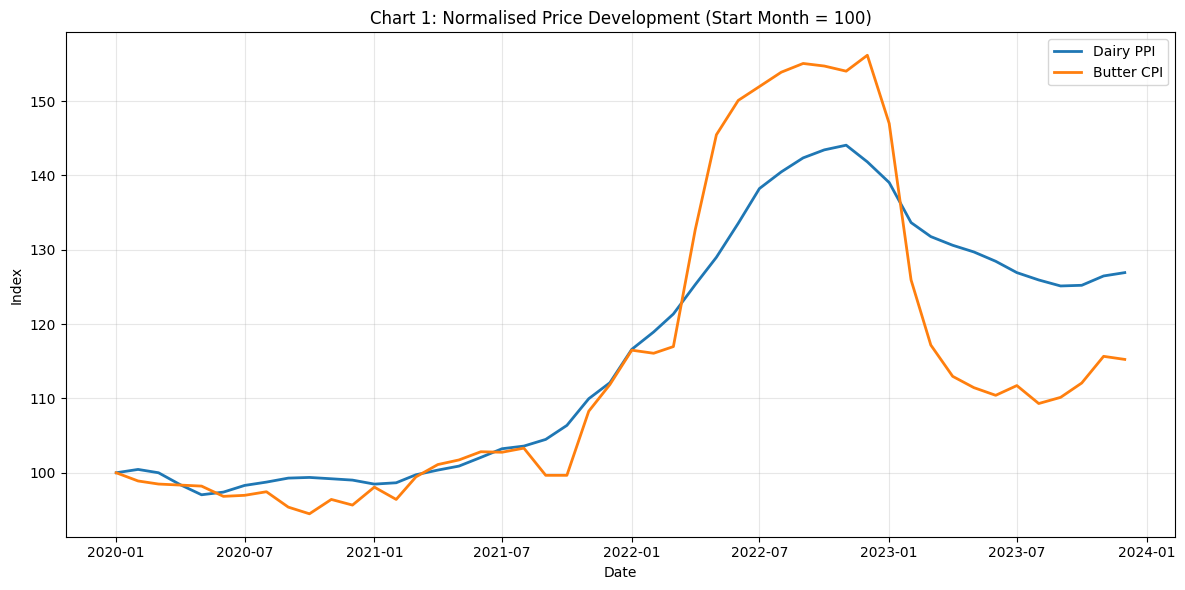

In [72]:
plot_line_chart(analysis_df)


## 13. Chart 2 – Grouped bar chart


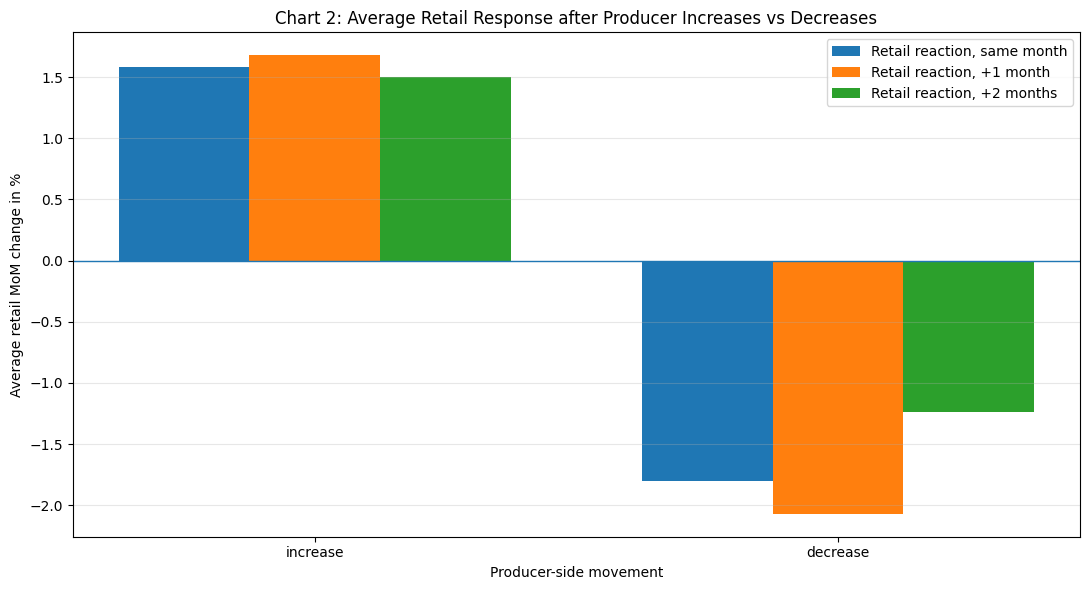

In [73]:
plot_grouped_bar_chart(summary_df)


## 14. Chart 3 – Boxplot


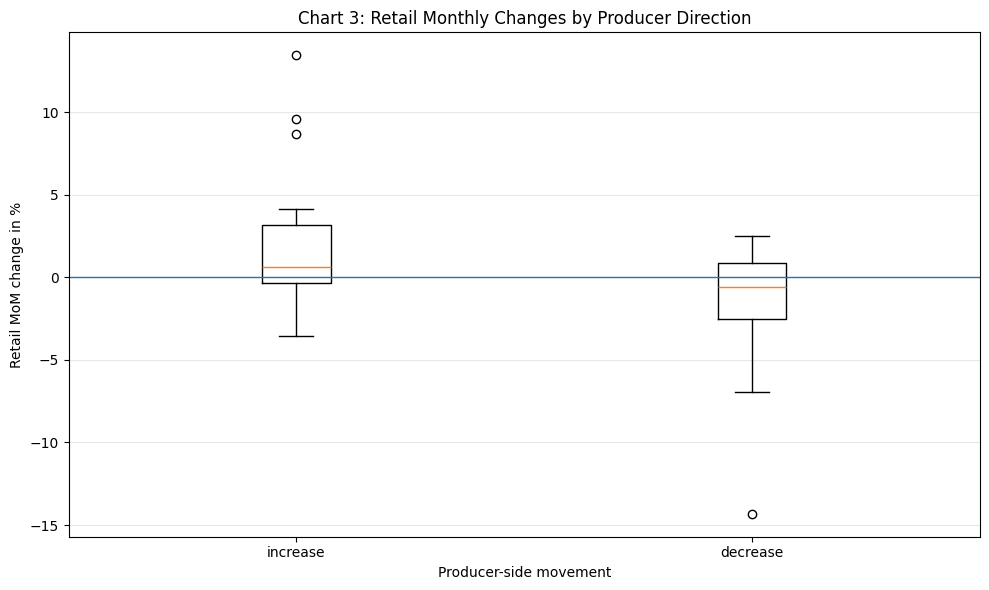

In [74]:
plot_boxplot(analysis_df)


## 15. Chart 4 – Scatter plot


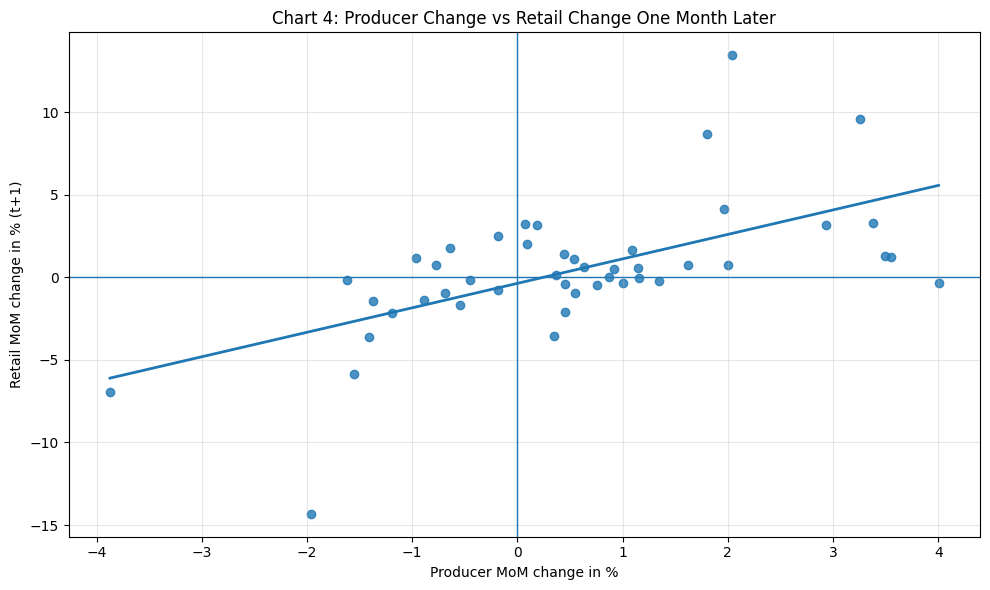

In [75]:
plot_scatter_chart(analysis_df)


## 16. Chart 5 – Heatmap


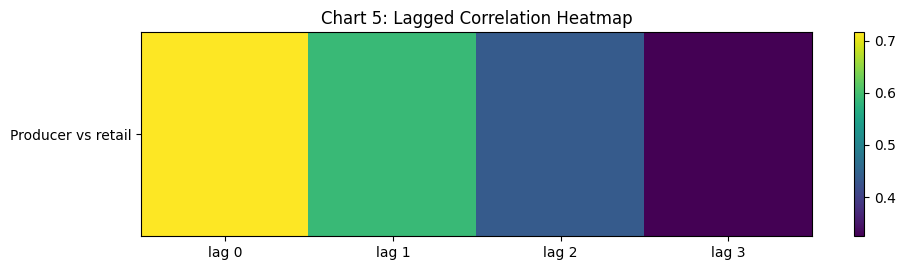

In [76]:
plot_heatmap(analysis_df)


## 17. Optional quick conclusion text

This final cell gives you a compact verbal takeaway for your presentation.


In [77]:
increase_row = summary_df.loc[summary_df["producer_direction"] == "increase"].iloc[0]
decrease_row = summary_df.loc[summary_df["producer_direction"] == "decrease"].iloc[0]

print("Suggested conclusion:")
print(
    "Retail butter prices in Germany show asymmetric transmission if price increases "
    "on the producer side are passed on faster or more strongly than producer-side "
    "decreases. In our descriptive results, this can be evaluated by comparing the "
    "average same-month and lagged retail reactions after producer increases versus "
    "producer decreases."
)
print(
    f"Same-month retail reaction after increases: {increase_row['avg_retail_lag0_pct']:.2f}%"
)
print(
    f"Same-month retail reaction after decreases: {decrease_row['avg_retail_lag0_pct']:.2f}%"
)
print(
    f"One-month-lag retail reaction after increases: {increase_row['avg_retail_lag1_pct']:.2f}%"
)
print(
    f"One-month-lag retail reaction after decreases: {decrease_row['avg_retail_lag1_pct']:.2f}%"
)


Suggested conclusion:
Retail butter prices in Germany show asymmetric transmission if price increases on the producer side are passed on faster or more strongly than producer-side decreases. In our descriptive results, this can be evaluated by comparing the average same-month and lagged retail reactions after producer increases versus producer decreases.
Same-month retail reaction after increases: 1.59%
Same-month retail reaction after decreases: -1.80%
One-month-lag retail reaction after increases: 1.68%
One-month-lag retail reaction after decreases: -2.07%
